In [3]:
#Loading all files we scrapped and concatenating them 
import os
import pandas as pd

folder_path = 'reddit_scrape_chunks/Hugging Face'
all_chunks = []

for filename in os.listdir(folder_path):
    if filename.endswith('.json') or filename.endswith('.csv'):
        full_path = os.path.join(folder_path, filename)
        if filename.endswith('.json'):
            df = pd.read_json(full_path)
        else:
            df = pd.read_csv(full_path)
        all_chunks.append(df)

# Combine all into one DataFrame
df_all = pd.concat(all_chunks, ignore_index=True)
print(df_all.head())


  subreddit                                          title      id  \
0   binance          Billionaire's secret to playing coin🥱  ndh93e   
1   binance                                        True af  nedva2   
2   binance                       Biggest SCAM of History!  njue1g   
3   binance  Will Binance Confiscate My $1.2M in 24 hours?  nctprg   
4   binance                           Well what can I say!  no3c4x   

                                                 url  score  \
0                https://i.redd.it/93addt2o3fz61.jpg   6072   
1                https://i.redd.it/1pfi3j8a3oz61.jpg   4533   
2                https://i.redd.it/9bwkz1p4l1171.jpg   4209   
3  https://www.reddit.com/r/binance/comments/nctp...   4016   
4                https://i.redd.it/p0ru885tp6271.jpg   3888   

                                                text  created_utc  \
0                                                      1621142572   
1                                                      1621251

In [5]:
comment_rows = []

for index, row in df_all.iterrows():
    comments = row.get('comments', [])
    for c in comments:
        sentiment_label = None

        # Extracting sentiment label safely
        if isinstance(c.get('sentiment'), dict):
            sentiment_label = c['sentiment'].get('label', 'neutral').capitalize()

        comment_rows.append({
            'comment_id': c.get('id'),
            'author': c.get('author'),
            'text': c.get('body'),
            'comment_created_utc': c.get('created_utc', row['created_utc']),
            'sentiment': sentiment_label
        })

df_comments = pd.DataFrame(comment_rows)
df_comments = df_comments.dropna(subset=['text']).reset_index(drop=True)

df_comments.tail()

,comment_id,author,text,comment_created_utc,sentiment
145285,m14jqpk,Luminousfiend47,He’s got experience with it before should be a...,1.733708e+09,Neutral
145286,m17izp1,Icy_Amphibian_JASMY,60 minutes edited their presidential interview...,1.733760e+09,Neutral
145287,m16paci,baconeggsavocado,Not sure they have any of those left.,1.733749e+09,Neutral
145288,m18hcvg,madtraxmerno,Cuckcoin,1.733770e+09,Neutral
145289,m18hjh0,luckywizard7,Exactly ! That's why I'm thinking it's a distr...,1.733771e+09,Neutral


In [5]:
sentiment_map = {'Negative': -1, 'Neutral': 0, 'Positive': 1}
df_comments['sentiment_score'] = df_comments['sentiment'].map(sentiment_map)

 Reddit Sentiment Time Series (Last 10 Days):

      date  sentiment_score most_common_sentiment
2025-07-15        -0.012903               Neutral
2025-07-16         0.126761               Neutral
2025-07-17         0.122449               Neutral
2025-07-18         0.000000               Neutral
2025-07-19         0.037344               Neutral
2025-07-20         0.087719               Neutral
2025-07-21         0.060870               Neutral
2025-07-22         0.000000               Neutral
2025-07-23         0.083333               Neutral
2025-07-24        -0.500000              Negative


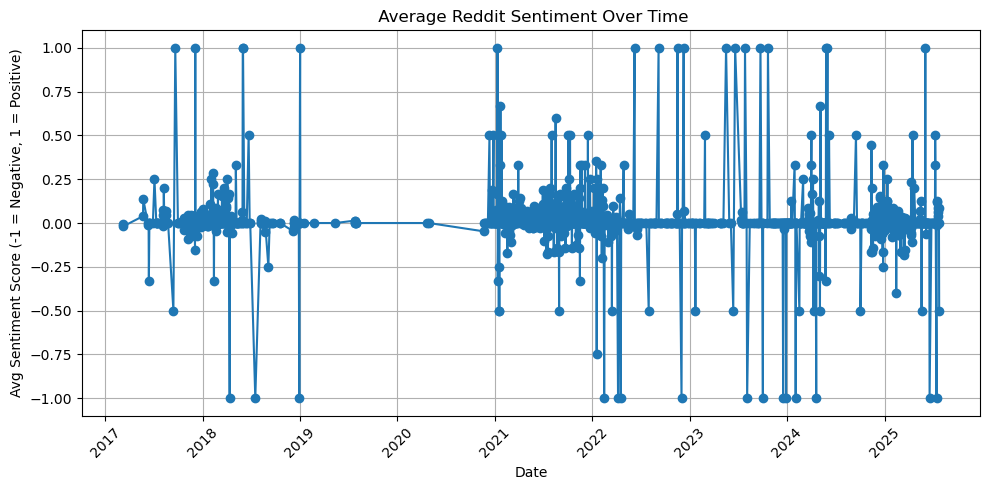

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Converting timestamps to datetime and extract date
df_comments['datetime'] = pd.to_datetime(df_comments['comment_created_utc'], unit='s')
df_comments['date'] = df_comments['datetime'].dt.floor('D')

# Average sentiment score per day
daily_sentiment_score = df_comments.groupby('date')['sentiment_score'].mean().reset_index()

#  Most common sentiment label per day
def mode_sentiment(x):
    return x.mode().iloc[0] if not x.mode().empty else 'Neutral'

daily_sentiment_label = df_comments.groupby('date')['sentiment'].apply(mode_sentiment).reset_index(name='most_common_sentiment')

# Merging both
daily_sentiment = pd.merge(daily_sentiment_score, daily_sentiment_label, on='date')

# Print table (last 10 entries)
print(" Reddit Sentiment Time Series (Last 10 Days):\n")
print(daily_sentiment.tail(10).to_string(index=False))

# Plotting graph
plt.figure(figsize=(10, 5))
plt.plot(daily_sentiment['date'], daily_sentiment['sentiment_score'], marker='o', linestyle='-')
plt.title(" Average Reddit Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Sentiment Score (-1 = Negative, 1 = Positive)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Basic stats
max_day = daily_sentiment.loc[daily_sentiment['sentiment_score'].idxmax()]
min_day = daily_sentiment.loc[daily_sentiment['sentiment_score'].idxmin()]
avg_sentiment = daily_sentiment['sentiment_score'].mean()
last_sentiment = daily_sentiment['sentiment_score'].iloc[-1]
first_sentiment = daily_sentiment['sentiment_score'].iloc[0]

# Trend direction
trend = "increasing" if last_sentiment > first_sentiment else "decreasing" if last_sentiment < first_sentiment else "stable"

# Printing conclusions
print("\n SENTIMENT INSIGHTS:")
print(f" Most Positive Day: {max_day['date'].date()} with score {round(max_day['sentiment_score'], 3)}")
print(f" Most Negative Day: {min_day['date'].date()} with score {round(min_day['sentiment_score'], 3)}")
print(f" Overall Sentiment Trend: {trend} (from {round(first_sentiment, 3)} to {round(last_sentiment, 3)})")
print(f" Average Sentiment Score: {round(avg_sentiment, 3)}")
print(f" Sentiment Range: {round(max_day['sentiment_score'] - min_day['sentiment_score'], 3)}")



 SENTIMENT INSIGHTS:
 Most Positive Day: 2017-09-20 with score 1.0
 Most Negative Day: 2018-04-12 with score -1.0
 Overall Sentiment Trend: decreasing (from -0.007 to -0.5)
 Average Sentiment Score: 0.018
 Sentiment Range: 2.0


In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np
from datetime import date, timedelta, datetime

#Preparing data
daily_sentiment['ordinal_date'] = daily_sentiment['date'].map(pd.Timestamp.toordinal)
X = daily_sentiment[['ordinal_date']]
y = daily_sentiment['sentiment_score']

#Training model
model = LinearRegression()
model.fit(X, y)

# Forecasting next 7 days from today
today = date.today()
forecast_dates = [today + timedelta(days=i) for i in range(7)]
forecast_ordinals = [d.toordinal() for d in forecast_dates]
forecast_scores = model.predict(np.array(forecast_ordinals).reshape(-1, 1))

#Label from score
def label_from_score(score):
    if score > 0.1:
        return "Positive "
    elif score < -0.1:
        return "Negative "
    else:
        return "Neutral "

#Showing results
print("\n 7-Day Reddit Sentiment Forecast:\n")
for d, s in zip(forecast_dates, forecast_scores):
    label = label_from_score(s)
    print(f"{d.strftime('%Y-%m-%d')}: Score = {round(s, 3)} → {label}")



 7-Day Reddit Sentiment Forecast:

2025-07-30: Score = 0.005 → Neutral 
2025-07-31: Score = 0.005 → Neutral 
2025-08-01: Score = 0.005 → Neutral 
2025-08-02: Score = 0.005 → Neutral 
2025-08-03: Score = 0.005 → Neutral 
2025-08-04: Score = 0.005 → Neutral 
2025-08-05: Score = 0.005 → Neutral 


C:\Users\Guppa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
